In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from models.bsm import BlackScholesModel

In [2]:
nifty_50_data = pd.read_csv('data/nifty_50_historical_data.csv', parse_dates=['Date'], index_col='Date')
nifty_50_data.sort_index(inplace=True)
nifty_50_data.dropna(inplace=True)
nifty_50_data


,Close,Open,High,Low,logReturn,pctReturn
Date,,,,,,
2024-11-12,23883.45,24225.80,24242.00,23839.15,-0.010738,-0.010681
2024-11-13,23559.05,23822.45,23873.60,23509.60,-0.013676,-0.013583
2024-11-14,23532.70,23542.15,23675.90,23484.15,-0.001119,-0.001118
2024-11-18,23453.80,23605.30,23606.80,23350.40,-0.003358,-0.003353
2024-11-19,23518.50,23529.55,23780.65,23464.80,0.002755,0.002759
...,...,...,...,...,...,...
2025-12-10,25758.00,25864.05,25947.65,25734.55,-0.003165,-0.003160
2025-12-11,25898.55,25771.40,25922.80,25693.25,0.005442,0.005457
2025-12-12,26046.95,25971.20,26057.60,25938.45,0.005714,0.005730


In [3]:
print(f"Mean Return: {nifty_50_data['logReturn'].mean()}\n\
Std Dev of Return: {nifty_50_data['logReturn'].std()}\n\
Annualized Return: {(1+nifty_50_data['logReturn'].mean())**252-1}\n\
Annualized Std Dev: {nifty_50_data['logReturn'].std()*np.sqrt(252)}")

Mean Return: 0.0002528572557571448
Std Dev of Return: 0.007663757733111906
Annualized Return: 0.06578538040684223
Annualized Std Dev: 0.12165838242037331


<Axes: title={'center': 'Nifty 50 Log Returns Over Time'}, xlabel='Date'>

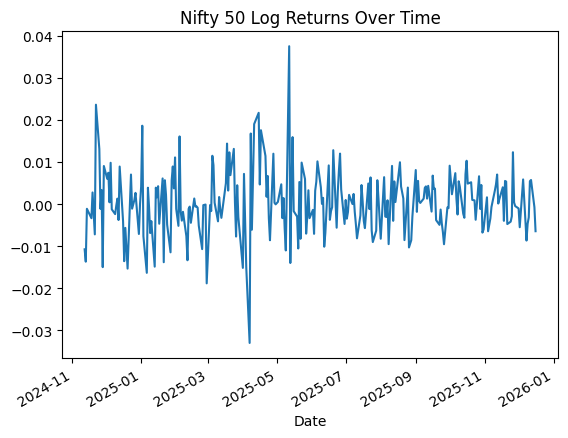

In [4]:
nifty_50_data['logReturn'].plot(title='Nifty 50 Log Returns Over Time')

In [5]:
option_data = pd.read_csv('data/nifty_50_options_chain.csv', parse_dates=['Date', 'Expiry Date'], index_col='Date')
option_data.sort_index(inplace=True)
option_data.dropna(inplace=True)
option_data

,Expiry Date,Option Type,Strike Price,Open Price,High Price,Low Price,Close Price,Last Price,Settlement Price,Volume,Value (₹ Lakhs),Premium Value (₹ Lakhs),Open Interest,Change in OI
Date,,,,,,,,,,,,,,
2025-11-12,2025-12-16,PE,"26,500.00",562.10,564.00,530.10,533.05,533.05,678.30,900,"2,43,42,540.00","4,92,540.00",450,450
2025-11-12,2025-12-16,CE,"25,900.00",431.00,473.65,407.60,468.90,468.90,445.75,3225,"8,49,13,192.50","13,85,692.50",1650,1650
2025-11-12,2025-12-16,CE,"27,450.00",51.00,51.00,13.00,21.00,20.00,21.00,1575,"4,32,69,191.25","35,441.25",675,675
2025-11-12,2025-12-16,CE,"26,200.00",252.05,303.20,252.05,286.75,286.75,286.75,1125,"2,97,94,035.00","3,19,035.00",750,750
2025-11-12,2025-12-16,CE,"25,800.00",488.00,541.65,468.90,505.50,504.80,505.50,3150,"8,28,46,500.00","15,76,500.00",975,975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-16,2025-12-16,PE,"24,850.00",0.95,1.00,0.05,0.10,0.05,"25,860.10",6546225,"1,62,67,71,36,168.75","34,44,918.75",565050,-216975
2025-12-16,2025-12-16,CE,"24,550.00","1,352.00","1,356.00","1,342.00","1,342.00","1,342.00","25,860.10",1275,"3,30,22,950.00","17,21,700.00",225,-1050
2025-12-16,2025-12-16,PE,"24,250.00",0.75,0.80,0.05,0.10,0.05,"25,860.10",1963650,"47,61,93,10,635.00","7,98,135.00",158625,-82650


In [6]:
sigma = [nifty_50_data['logReturn'].std() * np.sqrt(252)]*len(option_data)
r = [0.067]*len(option_data) #nse mentions 10% used to calc impl vol
S0 = pd.Series(nifty_50_data['Close'][date] for date in option_data.index)
K = option_data['Strike Price'].str.replace(",", "")
T = option_data['Expiry Date']-option_data.index
T = T.dt.days
bsm_prices_df = pd.DataFrame({'Date': list(option_data.index), \
                              'Type': list(option_data['Option Type']), \
                              'S0': list(S0), 'K': list(K), \
                                'T': list(T), 'sigma': list(sigma), \
                                'r': list(r), \
                                'Close Price': list(option_data['Close Price']), \
                                'LTP': list(option_data['Last Price'])})

In [7]:
bsm_prices_df['Date'] = pd.to_datetime(bsm_prices_df['Date'])
bsm_prices_df['S0'] = bsm_prices_df['S0'].astype(float)
bsm_prices_df['K'] = bsm_prices_df['K'].astype(float)
bsm_prices_df['T'] = bsm_prices_df['T'].astype(float)
bsm_prices_df['sigma'] = bsm_prices_df['sigma'].astype(float)
bsm_prices_df['r'] = bsm_prices_df['r'].astype(float)
bsm_prices_df['Close Price'] = bsm_prices_df['Close Price'].str.replace(',', '').astype(float)
bsm_prices_df['LTP'] = bsm_prices_df['LTP'].str.replace(',', '').astype(float)
bsm_prices_df

,Date,Type,S0,K,T,sigma,r,Close Price,LTP
0,2025-11-12,PE,25875.8,26500.0,34.0,0.121658,0.067,533.05,533.05
1,2025-11-12,CE,25875.8,25900.0,34.0,0.121658,0.067,468.90,468.90
2,2025-11-12,CE,25875.8,27450.0,34.0,0.121658,0.067,21.00,20.00
3,2025-11-12,CE,25875.8,26200.0,34.0,0.121658,0.067,286.75,286.75
4,2025-11-12,CE,25875.8,25800.0,34.0,0.121658,0.067,505.50,504.80
...,...,...,...,...,...,...,...,...,...
2754,2025-12-16,PE,25860.1,24850.0,0.0,0.121658,0.067,0.10,0.05
2755,2025-12-16,CE,25860.1,24550.0,0.0,0.121658,0.067,1342.00,1342.00
2756,2025-12-16,PE,25860.1,24250.0,0.0,0.121658,0.067,0.10,0.05
2757,2025-12-16,CE,25860.1,25400.0,0.0,0.121658,0.067,471.05,460.50


In [8]:
bsm_model = BlackScholesModel()
bsm_prices_df['BSM Price'] = [bsm_model.price_options(S0=row['S0'], \
                            K=row['K'], T=row['T']/252, r=row['r'],\
                            sigma=row['sigma'], option_type=row['Type']) for index, row in bsm_prices_df.iterrows()]

In [9]:
bsm_prices_df['BSM Price'] = bsm_prices_df['BSM Price'].round(2)
bsm_prices_df['Error vs Close'] = (bsm_prices_df['BSM Price'] - bsm_prices_df['Close Price']).round(2)
bsm_prices_df['Error vs LTP'] = (bsm_prices_df['BSM Price'] - bsm_prices_df['LTP']).round(2)
bsm_prices_df['Percent Error vs Close'] = ((bsm_prices_df['Error vs Close'] / bsm_prices_df['Close Price'])*100).round(5)
bsm_prices_df['Percent Error vs LTP'] = ((bsm_prices_df['Error vs LTP'] / bsm_prices_df['LTP'])*100).round(5)
bsm_prices_df

,Date,Type,S0,K,T,sigma,r,Close Price,LTP,BSM Price,Error vs Close,Error vs LTP,Percent Error vs Close,Percent Error vs LTP
0,2025-11-12,PE,25875.8,26500.0,34.0,0.121658,0.067,533.05,533.05,682.81,149.76,149.76,28.09493,28.09493
1,2025-11-12,CE,25875.8,25900.0,34.0,0.121658,0.067,468.90,468.90,571.37,102.47,102.47,21.85327,21.85327
2,2025-11-12,CE,25875.8,27450.0,34.0,0.121658,0.067,21.00,20.00,78.28,57.28,58.28,272.76190,291.40000
3,2025-11-12,CE,25875.8,26200.0,34.0,0.121658,0.067,286.75,286.75,419.18,132.43,132.43,46.18309,46.18309
4,2025-11-12,CE,25875.8,25800.0,34.0,0.121658,0.067,505.50,504.80,628.86,123.36,124.06,24.40356,24.57607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2754,2025-12-16,PE,25860.1,24850.0,0.0,0.121658,0.067,0.10,0.05,0.00,-0.10,-0.05,-100.00000,-100.00000
2755,2025-12-16,CE,25860.1,24550.0,0.0,0.121658,0.067,1342.00,1342.00,1310.26,-31.74,-31.74,-2.36513,-2.36513
2756,2025-12-16,PE,25860.1,24250.0,0.0,0.121658,0.067,0.10,0.05,0.00,-0.10,-0.05,-100.00000,-100.00000
2757,2025-12-16,CE,25860.1,25400.0,0.0,0.121658,0.067,471.05,460.50,460.27,-10.78,-0.23,-2.28850,-0.04995


In [10]:
print("Mean Percent Error vs Close Price:", bsm_prices_df['Percent Error vs Close'].mean())
print("Mean Percent Error vs LTP:", bsm_prices_df['Percent Error vs LTP'].mean())
print("Std Dev of Percent Error vs Close Price:", bsm_prices_df['Percent Error vs Close'].std())
print("Std Dev of Percent Error vs LTP:", bsm_prices_df['Percent Error vs LTP'].std())

Mean Percent Error vs Close Price: 58.53371710402319
Mean Percent Error vs LTP: 66.15813565422255
Std Dev of Percent Error vs Close Price: 142.9209353612916
Std Dev of Percent Error vs LTP: 339.216284254179


In [11]:
bsm_prices_df.to_csv('results/bsm_model_prices.csv', index=False)